# TODO 1.4.

- MAR assumption: generating coverage from the mag. field
    - repeat analysis with coverage masked data
- repeat MCAR analysis with min-max scaled input, see if different
- do MCAR analysis with more missingness percentages (i.e. every 5 % or so) for the top performing methods

In [2]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

from pathlib import Path
from itertools import product
from sklearn.impute import KNNImputer
from numpy.lib.stride_tricks import sliding_window_view
from IPython.display import clear_output

from aipad.padimputer import PADImputer
from aipad.spacecrafts import SoloConstants, WindConstants
from aipad.datahandler import WindDataHandler
from aipad.pad_imputation import (
    make_train_test, calculate_scores, save_results, pad_histogram, induce_missingness,
    target_from_prediction)

In [2]:
bins = 8
time_avg_min = 1
avg_bin = f"{time_avg_min}min_{bins}bins"

file_path = Path("./data/hdf5") / f"wind_{avg_bin}.h5"
cov_path = Path("./data/coverages") / avg_bin
plot_path = Path(f"./plots/")

plot_path.mkdir(exist_ok=True)

solo = SoloConstants()
wind = WindConstants()

### Simple imputation strategies: row/column mean, average of forward and backward fill, linear interpolation, KNN without train-test split


In [ ]:
import subprocess
imputer = PADImputer()

miss_pcts = np.arange(10, 80, 5)

events = pd.read_csv("events.csv")
for event_no in range(len(events)):
    event_key = events.values[event_no][0]
    if event_key.split("-")[0] < "20121007":
        continue
    for method, miss_pct in product(["fill_average", "interp", "cubic"], miss_pcts):
        rc = subprocess.run(("python3", "analysis.py", event_key, method, "time", str(miss_pct)))
    clear_output()

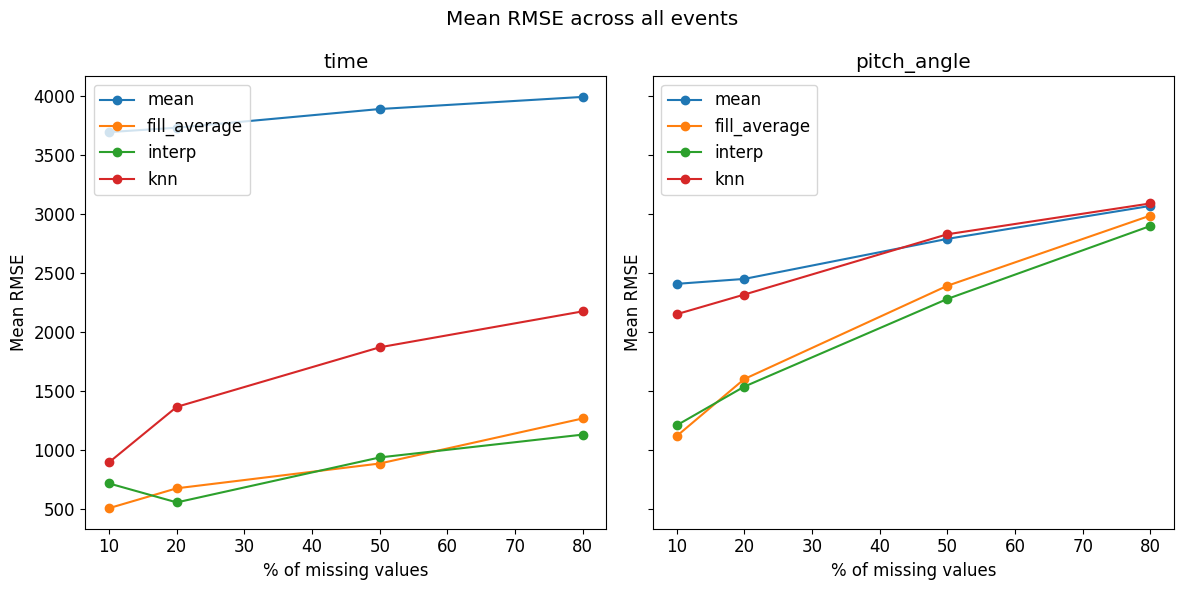

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os

results_path = Path("/home/ojsant/gradu/results")
means = pd.read_csv("/home/ojsant/gradu/results/20120728-220737.csv", header=[0, 1], index_col=[0, 1])["rmse_mean"]
stds = means.copy()
base_arr = np.zeros((8,4))
dfs = []
for i, csv in enumerate(os.listdir(results_path)):
    dfs.append(pd.read_csv(results_path / csv, header=[0, 1], index_col=[0, 1])["rmse_mean"].to_numpy())

dfs = np.stack(dfs)
mean_rmses = np.nanmean(dfs, axis=0)
means.iloc[:] = mean_rmses
std_rmses = np.std(dfs, axis=0, ddof=1)
stds.iloc[:] = std_rmses

pcts = means.columns.astype(int)

# Mistral prompt
row_vars = ["time", "pitch_angle"]
col_vars = ["mean", "fill_average", "interp", "knn"]

fig, axs = plt.subplots(ncols=2, figsize=(12, 6), sharex=True, sharey=True)

fig.suptitle("Mean RMSE across all events")
# Plot data
for i, axis in enumerate(row_vars):
    for method in col_vars:
        axs[i].plot(pcts, means.loc[(method, axis)].values, "o-", label=method)
    axs[i].set_title(axis)
    axs[i].legend(loc="upper left")
    axs[i].set_xlabel(r"% of missing values")
    axs[i].set_ylabel("Mean RMSE")
plt.tight_layout()
plt.show()

In [7]:
means

miss_percent                       10           20           50           80
method       axis                                                           
mean         time         3692.976521  3730.494788  3888.736752  3991.436310
             pitch_angle  2407.177928  2448.920658  2788.398070  3067.650205
fill_average time          506.432205   674.781572   884.834853  1266.804028
             pitch_angle  1116.443538  1600.408793  2390.727702  2985.623926
interp       time          715.785867   555.204030   936.324184  1129.791928
             pitch_angle  1207.903137  1536.340768  2279.179908  2897.480531
knn          time          895.153573  1364.804047  1869.723454  2174.275594
             pitch_angle  2149.783500  2316.379922  2827.288760  3088.528302

### KNN with vs. without training

In [ ]:
import subprocess
miss_pcts = [10, 20, 50, 80]
for n_neighbors in [1, 5, 10, 15]:
    for miss_pct in miss_pcts:
        rc = subprocess.run(("python3", "knn_train_test_analysis.py", str(miss_pct), str(n_neighbors)))

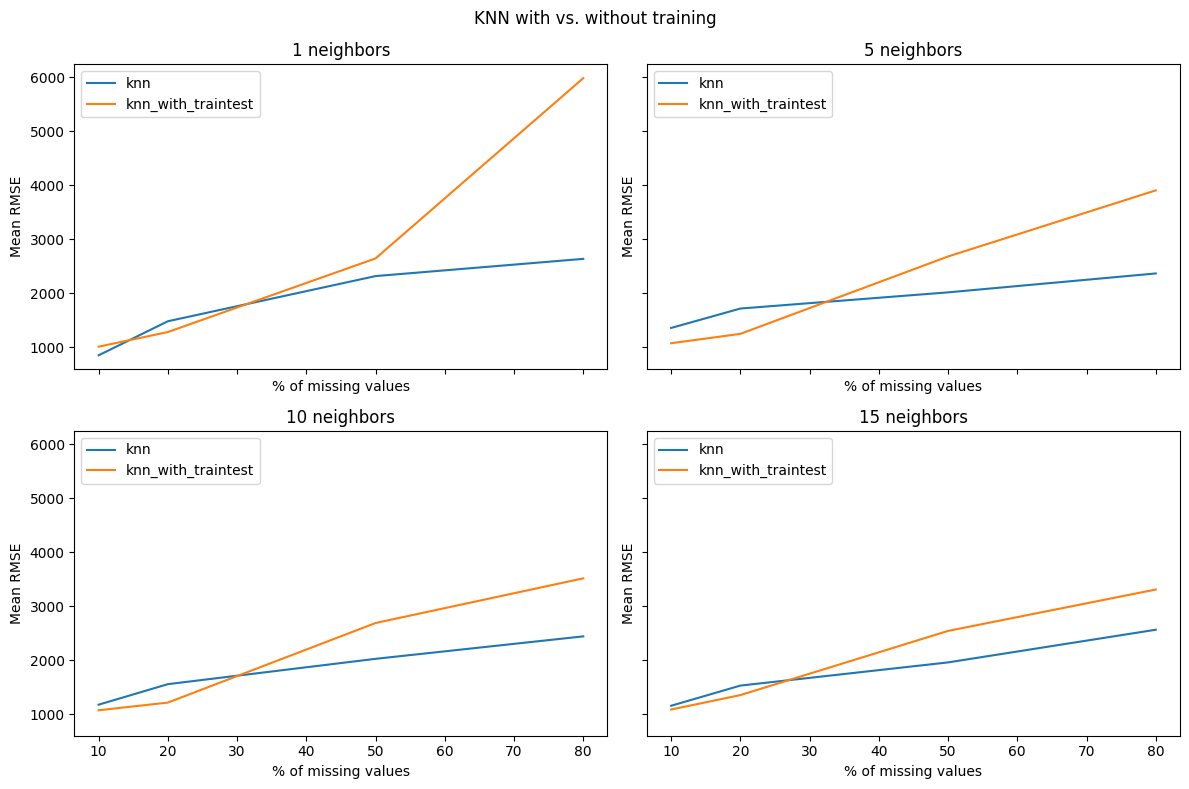

In [10]:
import matplotlib.pyplot as plt
import numpy as np


os.chdir("/home/ojsant/gradu/knn_results")
means = pd.read_csv("/home/ojsant/gradu/knn_results/20120102-153731.csv", header=0, index_col=[0, 1])
# stds = means.copy()
base_arr = np.zeros((8,4))
dfs = []
for i, csv in enumerate(os.listdir()):
    try:
        dfs.append(pd.read_csv(csv, header=0, index_col=[0, 1]).to_numpy())
    except IsADirectoryError:
        continue

dfs = np.stack(dfs)
mean_rmses = np.nanmean(dfs, axis=0)
means.iloc[:] = mean_rmses
# std_rmses = np.std(dfs, axis=0, ddof=1)
# stds.iloc[:] = std_rmses
pcts = means.columns.astype(int)

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(12, 8), sharex=True, sharey=True)
fig.suptitle("KNN with vs. without training")
# Plot data
for i, n_neighbors in enumerate([1, 5, 10, 15]):
    ax = axs.ravel()[i]
    ax.plot(pcts, means.loc[("knn", f"{n_neighbors}n")].values, label="knn")
    ax.plot(pcts, means.loc[("knn_with_traintest", f"{n_neighbors}n")].values, label="knn_with_traintest")
    ax.legend(loc="upper left")
    ax.set_title(f"{n_neighbors} neighbors")
    ax.set_xlabel(r"% of missing values")
    ax.set_ylabel("Mean RMSE")
plt.tight_layout()

In [35]:
means

10           20           50  \
method             n_neighbors                                          
knn                1n            855.486714  1485.837765  2322.312293   
                   5n           1362.052511  1721.245381  2020.851684   
                   10n          1173.704813  1553.739106  2022.826144   
                   15n          1153.908294  1527.181089  1956.550005   
knn_with_traintest 1n           1015.086366  1286.312706  2649.260626   
                   5n           1078.768963  1252.493870  2685.596241   
                   10n          1070.245019  1212.493320  2685.854895   
                   15n          1084.319932  1351.491811  2539.750224   

                                         80  
method             n_neighbors               
knn                1n           2641.019495  
                   5n           2370.978847  
                   10n          2438.823655  
                   15n          2561.492452  
knn_with_traintest 1n           5986.730115  
                   5n           3909.078625  
                   10n          3513.086140  
                   15n          3306.354593

### KNNImputer CV (with blocks)

In [ ]:
# Stacking of training cases for KNN imputer:
# concatenate 5 successive rows to one feature vector (5 * 180 = 900 features)
trains = []
for train in X_train:
    train_stacked = sliding_window_view(train, window_shape=(5,180)).reshape(-1, 5 * train.shape[1])   # ChatGPT solution
    trains.append(train_stacked)

X_train_stacked = np.vstack(trains)

In [ ]:
import logging
import sys
filehandler = logging.FileHandler(filename="./logs/cv_results.log", encoding="utf-8")
streamhandler = logging.StreamHandler(sys.stdout)
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(message)s', datefmt='%m/%d/%Y %H:%M:%S', handlers=[filehandler, streamhandler], force=True)

def form_test_matrices_blocks(model: KNNImputer, X_test: np.ndarray,
                       y_test: np.ndarray, n_samples=10, sample_loc=120) -> list:
    true = X_test[sample_loc:sample_loc+n_samples]
    test = y_test[sample_loc:sample_loc+n_samples]
    reduced = np.where(np.isfinite(test), true, np.nan)
    
    reduced_reshaped = reduced.reshape((2, 900))
    pred_full_reshaped = model.transform(reduced_reshaped)
    pred_full = pred_full_reshaped.reshape((10, 180))

    pred = np.where((np.isnan(reduced)
                    & np.isfinite(true)
                    & np.meshgrid(np.isfinite(reduced).any(axis=1), np.arange(0, reduced.shape[1]),
                                  indexing="ij")[0]),
                    pred_full, np.nan)
    target = np.where(np.isfinite(pred), true, np.nan)

    return [true, reduced, pred_full, pred, target]

# Model selection CV
neighbors = np.arange(0, 31, 5)
neighbors[0] = 1
#weights = ["distance", "uniform"]      10.2. no noticeable difference between these
n_splits = 3
n_events = 20
n_samples = 10
sample_loc = 120 # onset is located at two hours after start of the window

# Cross validation: shift train-test split by one 3 times (a sort of 3-fold CV),
# but test only 10 samples in each event (after onset) and only 20 events in each fold

for n in neighbors:
    imputer = KNNImputer(n_neighbors=n, weights="distance", keep_empty_features=True)
    
    for shift in range(n_splits):
        logging.info(f"KNN neighbors={n}, split {shift}")
        result_df = pd.DataFrame()
        (X_train, X_test, y_train, y_test,
        I_train, I_test, meta_train, meta_test) = make_train_test(hist_arr, reduced_hist_arr,
                                                                intensity_arr, metadata_arr,
                                                                n=n_splits, shift=shift)
        trains = []
        for train in X_train:
            train_stacked = sliding_window_view(train, window_shape=(5, train.shape[1])).reshape(-1, 5 * train.shape[1])   # ChatGPT solution
            trains.append(train_stacked)

        X_train_stacked = np.vstack(trains)
        imputer.fit(X_train_stacked)
        scores = []
        for j in range(20):
            res = form_test_matrices_blocks(imputer, X_test[j], y_test[j])
            # plot_results(model, res, "rmse", I_test[j], sc=wind, cov_sc=solo,
            #              save_path=plot_path / "knnimputer" / "crossvalidation" / f"knn_{n}_{w}_split_{shift}_results_{j}.png")
            
            # Score on n_samples samples during main event
            score = calculate_scores(res[3],
                                     res[4], "rmse")
            result_df = save_results(imputer, res, meta_test[j], "rmse", Path(f"./knn_{n}_split_{shift}_results.csv"))
            scores.append(score)
            logging.info(f"Score for test event {j}: {score}")

        clear_output()
        logging.info(f"KNN neighbors={n}: CV score on fold {shift}={np.mean(scores):.4f}")


02/10/2026 12:46:53 KNN neighbors=15, weights=uniform: CV score on fold 2=2407.7693


Cubic 1D interpolation (70 % MCAR)
Mean: 0.2663104282277767
Std: 0.04169726738577136


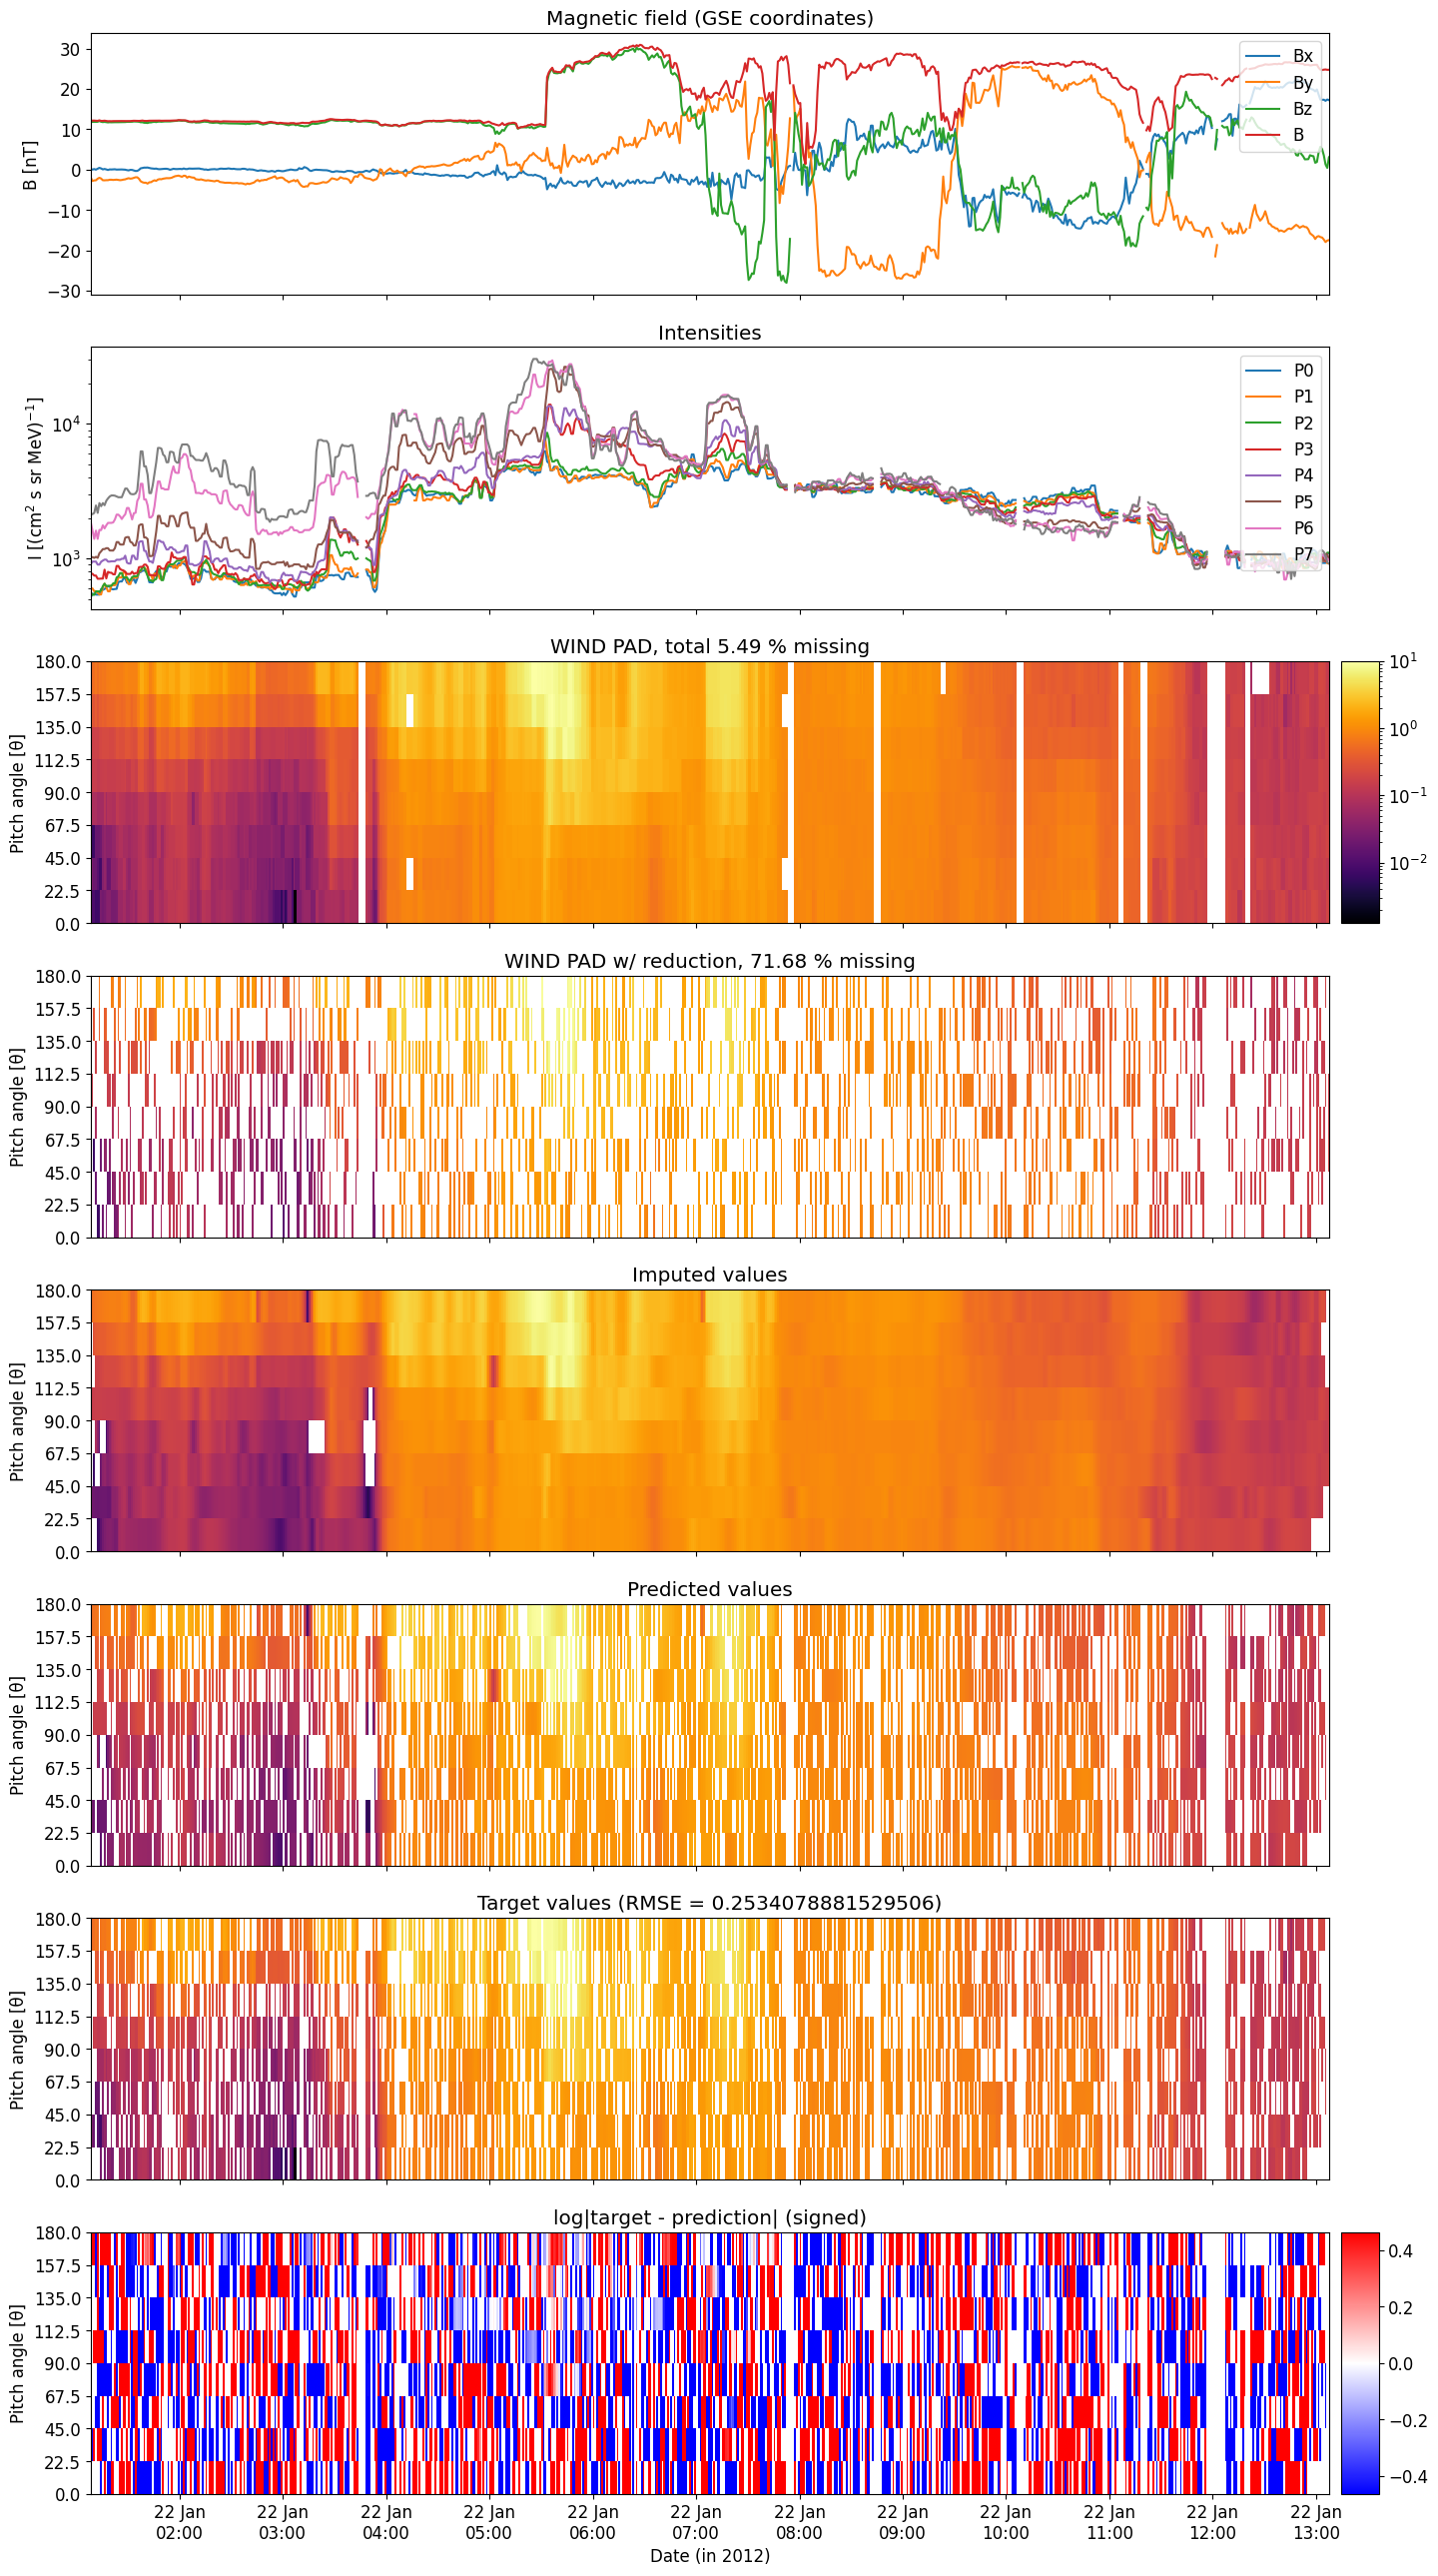

In [8]:
from aipad.pad_imputation import load_event_data, plot_results
from scipy.interpolate import griddata

def min_max_scale(a, interval=(0, 1)):
    return interval[0] + (interval[1] - interval[0])*(a - np.nanmin(a)) / (np.nanmax(a) - np.nanmin(a))

imputer = PADImputer(method="cubic", axis=0, cubic_dim=1)
repeats = 100
with h5py.File(file_path, 'r') as hdf:
    event_key = "20120122-030734"
    df = pd.read_csv(f"/home/ojsant/gradu/results/{event_key}.csv", header=0, index_col=[0, 1])
    event_data = load_event_data(hdf, event_key, wind)

    I_data = event_data["Intensity"]
    B_data = event_data["MagField"]
    cov_data = event_data["Coverage"]
    times = event_data["Intensity_attrs"]["Epoch"]

    I_min_max = min_max_scale(I_data.values, (0,10))

    X, Y, true = pad_histogram(wind, I_min_max, cov_data, 8)
    X, Y = np.meshgrid(np.arange(true.shape[0]), np.arange(true.shape[1]), indexing="ij")
    scores = []
    for i in range(repeats):
        reduced_cov, mask = induce_missingness(cov_data, 0.7)
        Xr, Yr, reduced = pad_histogram(wind, I_min_max, reduced_cov, 8)
        imputed = imputer.transform(reduced)
        target, pred = target_from_prediction(true, reduced, imputed)
        score = calculate_scores(target, pred, "rmse")
        scores.append(score)

    mean = np.mean(scores)
    std = np.std(scores, ddof=1)
    print("Cubic 1D interpolation (70 % MCAR)")
    print("Mean:", mean)
    print("Std:", std)
    pa = np.linspace(0.5*180/bins, (bins-0.5)*180/bins, bins)
    plot_results(pa, I_data, B_data, true, reduced, imputed, "rmse", wind, solo, save_plot=False)


Clough-Tocher (piecewise cubic, curvature-minimizing) 2D interpolation (70 % MCAR)
Mean: 0.1984759526201289
Std: 0.014780895624314179


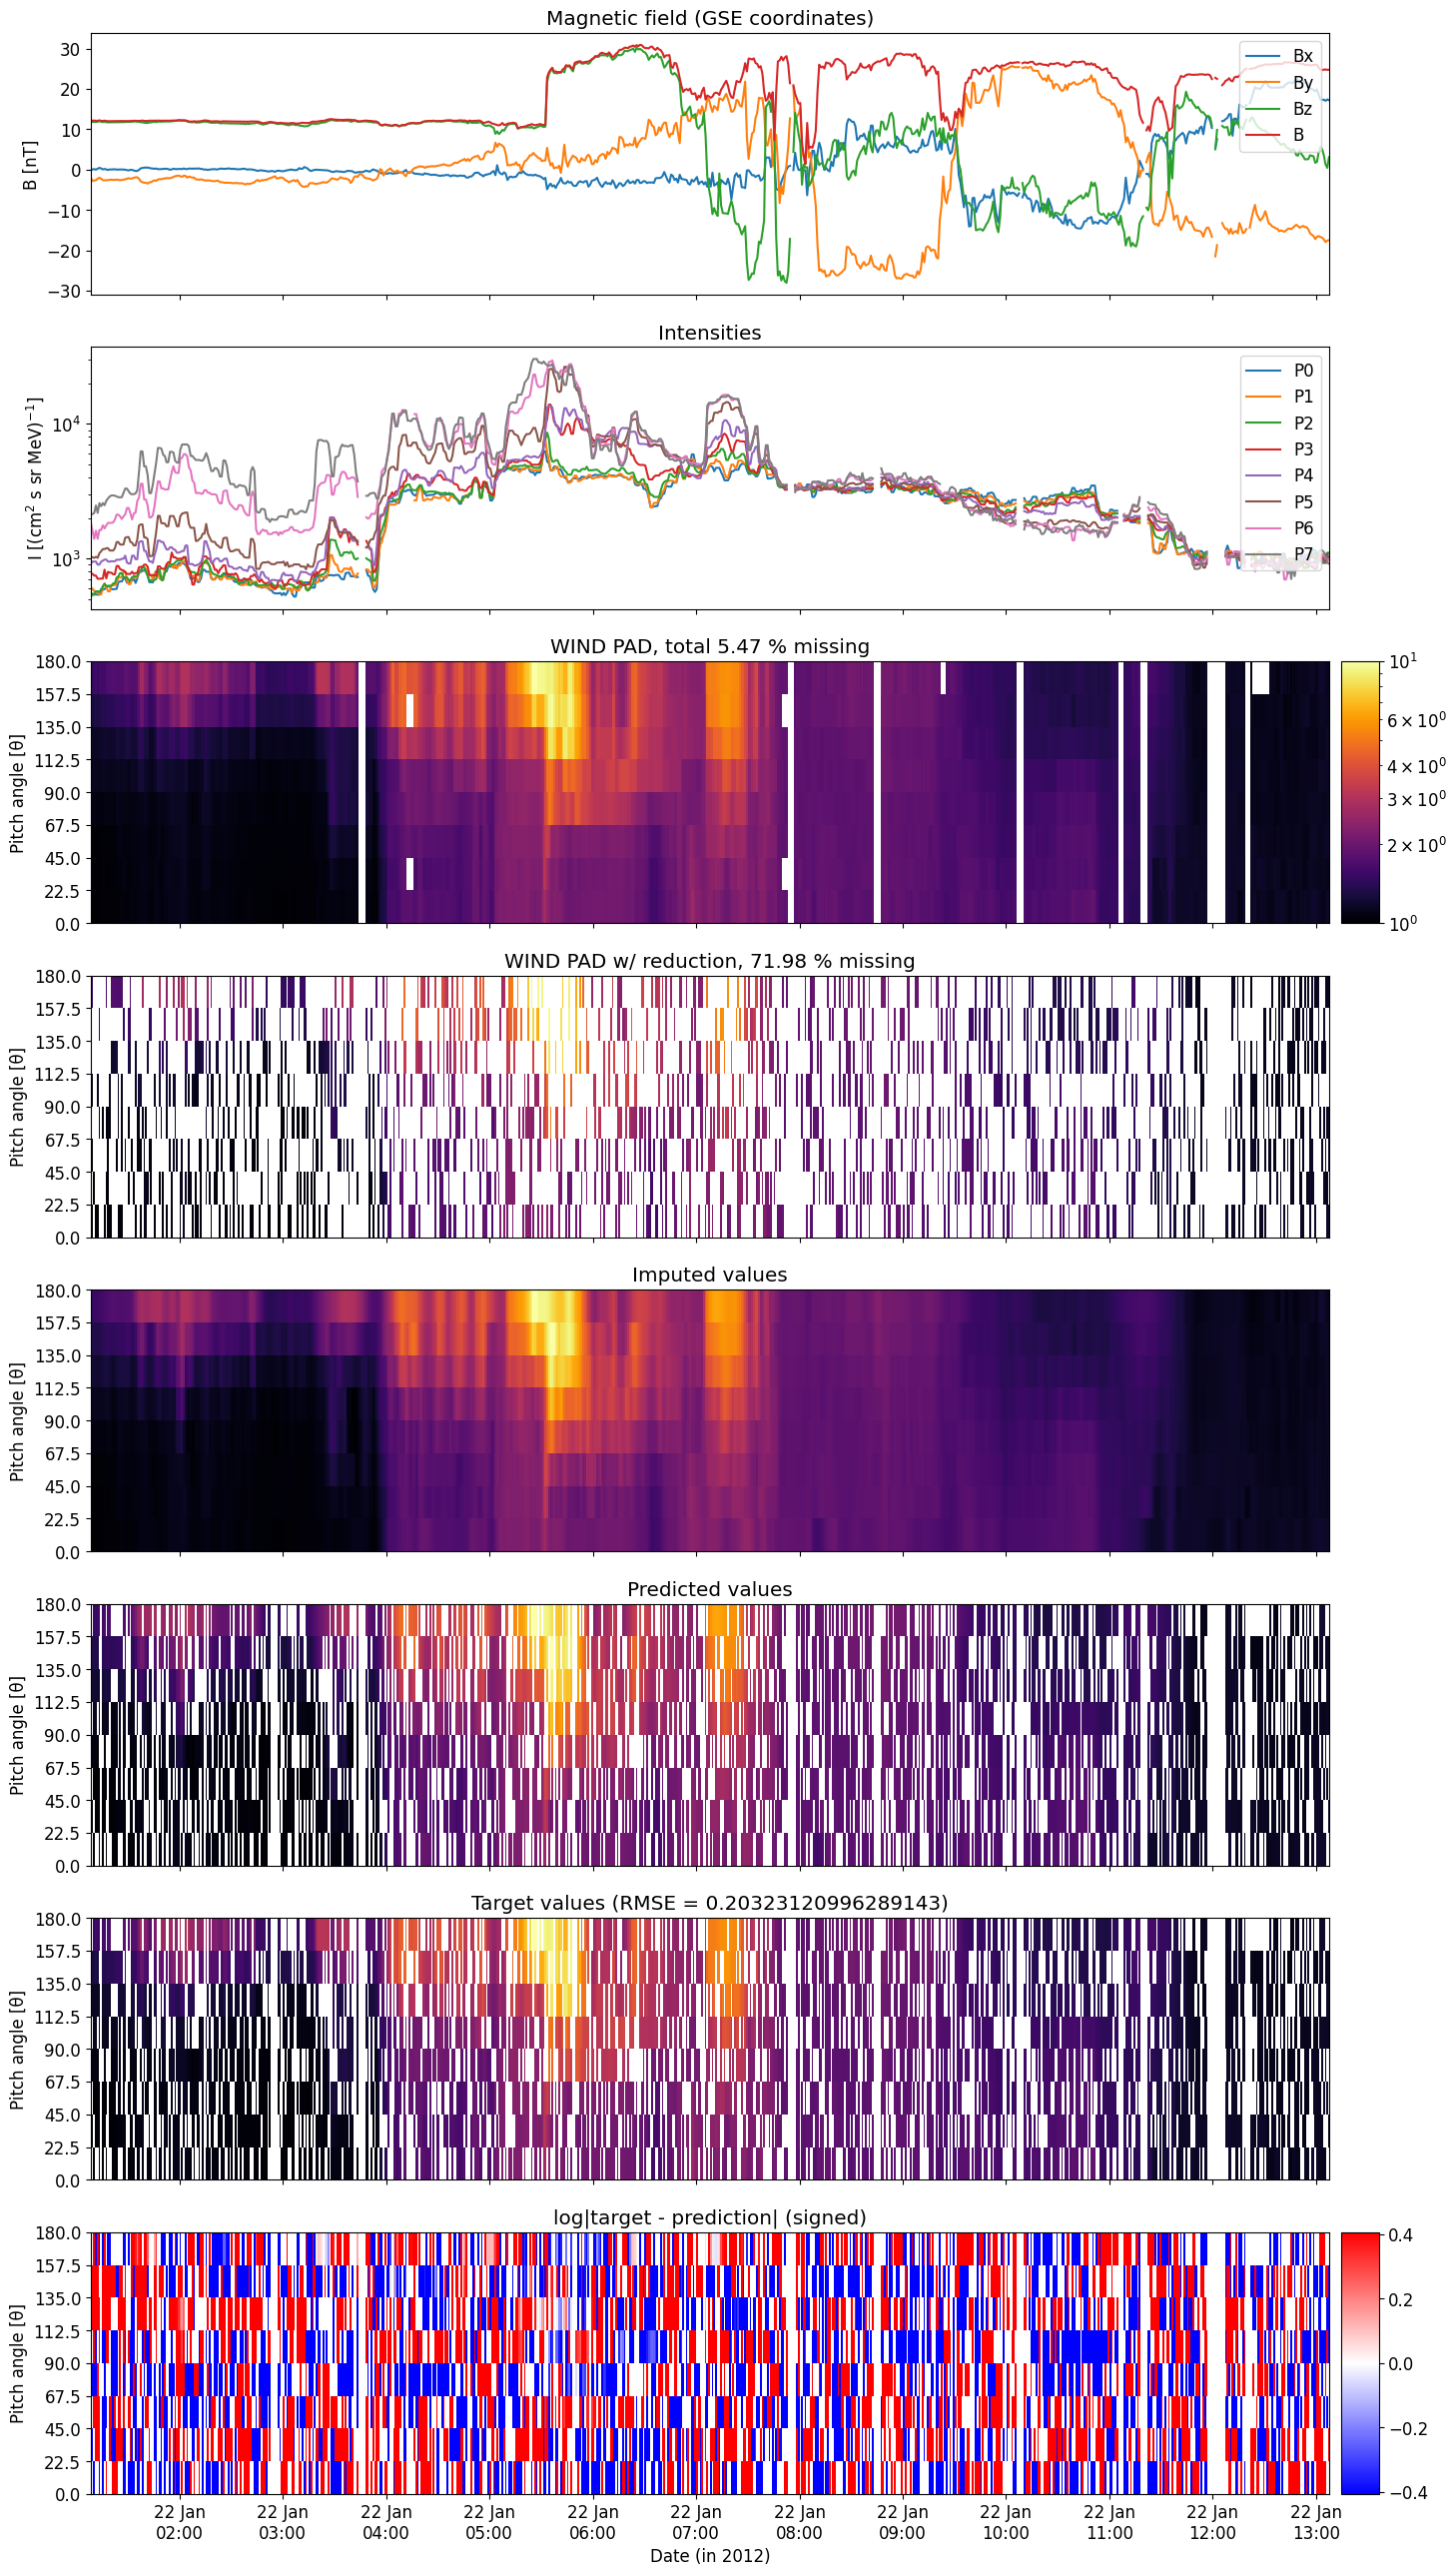

In [3]:
from aipad.pad_imputation import load_event_data, plot_results
from scipy.interpolate import griddata

def min_max_scale(a, interval=(0, 1)):
    return interval[0] + (interval[1] - interval[0])*(a - np.nanmin(a)) / (np.nanmax(a) - np.nanmin(a))

imputer = PADImputer(method="cubic", axis=0, cubic_dim=2)
repeats = 100
with h5py.File(file_path, 'r') as hdf:
    event_key = "20120122-030734"
    df = pd.read_csv(f"/home/ojsant/gradu/results/{event_key}.csv", header=0, index_col=[0, 1])
    event_data = load_event_data(hdf, event_key, wind)

    I_data = event_data["Intensity"]
    B_data = event_data["MagField"]
    cov_data = event_data["Coverage"]
    times = event_data["Intensity_attrs"]["Epoch"]

    I_min_max = min_max_scale(I_data.values, (1,10))

    X, Y, true = pad_histogram(wind, I_min_max, cov_data, 8)
    X, Y = np.meshgrid(np.arange(true.shape[0]), np.arange(true.shape[1]), indexing="ij")
    scores = []
    for i in range(repeats):
        reduced_cov, mask = induce_missingness(cov_data, 0.7)
        Xr, Yr, reduced = pad_histogram(wind, I_min_max, reduced_cov, 8)
        imputed = imputer.transform(reduced)
        target, pred = target_from_prediction(true, reduced, imputed)
        score = calculate_scores(target, pred, "rmse")
        scores.append(score)

    mean = np.mean(scores)
    std = np.std(scores, ddof=1)
    print("Clough-Tocher (piecewise cubic, curvature-minimizing) 2D interpolation (70 % MCAR)")
    print("Mean:", mean)
    print("Std:", std)
    pa = np.linspace(0.5*180/bins, (bins-0.5)*180/bins, bins)
    plot_results(pa, I_data, B_data, true, reduced, imputed, "rmse", wind, solo, save_plot=False)

In [1]:
imputer = PADImputer()
repeats = 100
with h5py.File(file_path, 'r') as hdf:
    
    df = pd.read_csv(f"./results/{event_key}.csv", header=[0, 1], index_col=[0, 1])
    
    event_data = load_event_data(hdf, event_key, wind)

    I_data = min_max_scale(event_data["Intensity"], (1, 10))
    B_data = event_data["MagField"]
    cov_data = event_data["Coverage"]
    times = event_data["Intensity_attrs"]["Epoch"]

    X, Y, true = pad_histogram(wind, I_data.values, cov_data, 8)
    imputer.method = "interp"
    imputer.axis = 0
    miss_percent = "70"
    scores = []
    
    for i in range(repeats):
        reduced_cov, mask = induce_missingness(cov_data, int(miss_percent) / 100)
        X, Y, reduced = pad_histogram(wind, I_data.values, reduced_cov, 8)
        imputed = imputer.fit_transform(reduced)
        target, pred = target_from_prediction(true, reduced, imputed)
        score = calculate_scores(target, pred, "rmse")
        scores.append(score)

    scores = np.array(scores)
    mean = scores.mean()
    std = scores.std(ddof=1)
    print("Linear 1D interpolation in time direction (70 % MCAR)")
    print("Mean:", mean)
    print("Std:", std)
    
    plot_results(Y[0], I_data, B_data, true, reduced, imputed, "rmse", wind, solo,
                 save_plot=False)

NameError: name 'PADImputer' is not defined

In [ ]:
from anisotropy.solo_methods import angle_between
from tqdm import tqdm

def calc_coverage(mag_data):
    opening = 40
    mag_vec = np.array([mag_data.Bx.to_numpy(), mag_data.By.to_numpy(), mag_data.Bz.to_numpy()])
    pointing_sun = np.array([-0.81915206, 0.57357645, 0.])
    pointing_asun = np.array([0.81915206, -0.57357645, 0.])
    pointing_north = np.array([0.30301532, 0.47649285, -0.8253098])
    pointing_south = np.array([-0.30301532, -0.47649285, 0.8253098])
    pointing_arr = np.vstack((pointing_sun, pointing_asun, pointing_north, pointing_south))

    pointing_sun = pointing_arr[0,:]
    pointing_asun = pointing_arr[1,:]
    pointing_north = pointing_arr[2,:]
    pointing_south = pointing_arr[3,:]
    pa_sun = np.ones(len(mag_data.Bx.to_numpy())) * np.nan
    pa_asun = np.ones(len(mag_data.Bx.to_numpy())) * np.nan
    pa_north = np.ones(len(mag_data.Bx.to_numpy())) * np.nan
    pa_south = np.ones(len(mag_data.Bx.to_numpy())) * np.nan

    for i in tqdm(range(len(mag_data.Bx.to_numpy()))):
        pa_sun[i] = np.rad2deg(angle_between(pointing_sun, mag_vec[:, i]))
        pa_asun[i] = np.rad2deg(angle_between(pointing_asun, mag_vec[:, i]))
        pa_north[i] = np.rad2deg(angle_between(pointing_north, mag_vec[:, i]))
        pa_south[i] = np.rad2deg(angle_between(pointing_south, mag_vec[:, i]))
    
    sun_min = pa_sun - opening/2
    sun_max = pa_sun + opening/2
    asun_min = pa_asun - opening/2
    asun_max = pa_asun + opening/2
    north_min = pa_north - opening/2
    north_max = pa_north + opening/2
    south_min = pa_south - opening/2
    south_max = pa_south + opening/2
    cov_sun = pd.DataFrame({'min': sun_min, 'center': pa_sun, 'max': sun_max}, index=mag_data.index)
    cov_asun = pd.DataFrame({'min': asun_min, 'center': pa_asun, 'max': asun_max}, index=mag_data.index)
    cov_north = pd.DataFrame({'min': north_min, 'center': pa_north, 'max': north_max}, index=mag_data.index)
    cov_south = pd.DataFrame({'min': south_min, 'center': pa_south, 'max': south_max}, index=mag_data.index)
    keys = [('sun'), ('asun'), ('north'), ('south')]
    coverage = pd.concat([cov_sun, cov_asun, cov_north, cov_south], keys=keys, axis=1)
    return coverage

cov = calc_coverage(B_data)
cov

100%|██████████| 1440/1440 [00:00<00:00, 9627.54it/s]


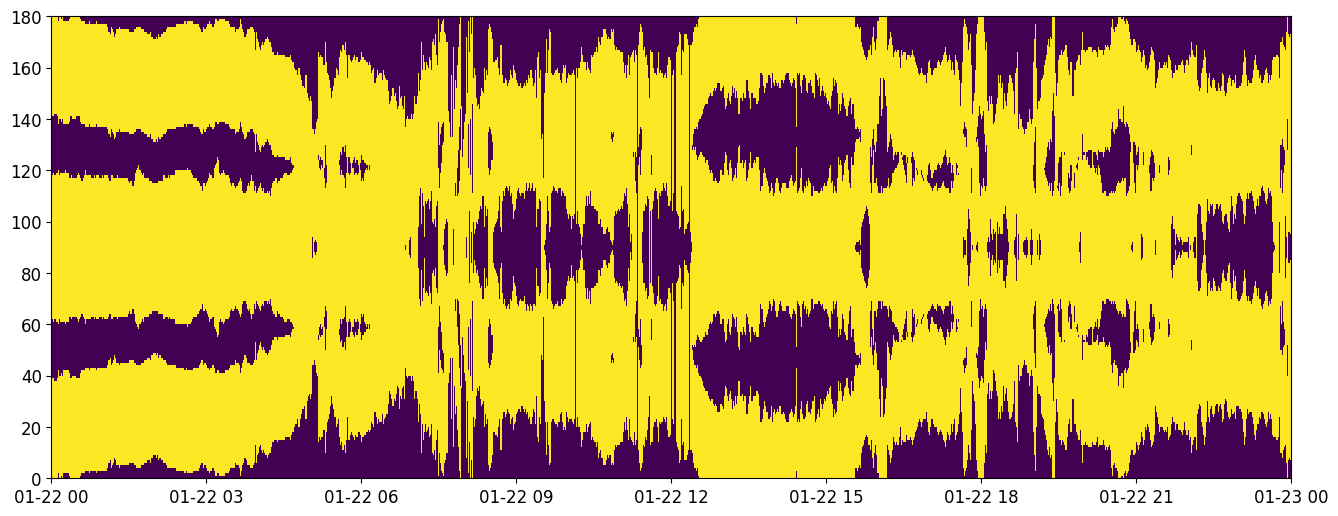

In [9]:
from aipad.pad_imputation import convert_to_bool_coverage

X, Y, wind_cov_bool = convert_to_bool_coverage(cov, solo, bins=180)
fig, ax = plt.subplots(figsize=(16,6))
ax.pcolormesh(X, Y, wind_cov_bool)

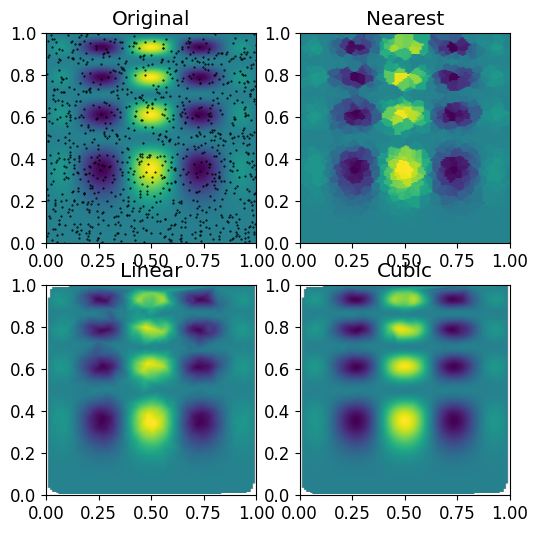

In [88]:
def func(x, y):
    return x*(1-x)*np.cos(4*np.pi*x) * np.sin(4*np.pi*y**2)**2

grid_x, grid_y = np.mgrid[0:1:100j, 0:1:200j]

rng = np.random.default_rng()
points = rng.random((1000, 2))
values = func(points[:,0], points[:,1])

from scipy.interpolate import griddata
grid_z0 = griddata(points, values, (grid_x, grid_y), method='nearest')
grid_z1 = griddata(points, values, (grid_x, grid_y), method='linear')
grid_z2 = griddata(points, values, (grid_x, grid_y), method='cubic')


import matplotlib.pyplot as plt
plt.subplot(221)
plt.imshow(func(grid_x, grid_y).T, extent=(0,1,0,1), origin='lower')
plt.plot(points[:,0], points[:,1], 'k.', ms=1)
plt.title('Original')
plt.subplot(222)
plt.imshow(grid_z0.T, extent=(0,1,0,1), origin='lower')
plt.title('Nearest')
plt.subplot(223)
plt.imshow(grid_z1.T, extent=(0,1,0,1), origin='lower')
plt.title('Linear')
plt.subplot(224)
plt.imshow(grid_z2.T, extent=(0,1,0,1), origin='lower')
plt.title('Cubic')
plt.gcf().set_size_inches(6, 6)
plt.show()

In [ ]:
%matplotlib widget

# importing required libraries
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import LinearNDInterpolator
import matplotlib.pyplot as plt

# creating figure
fig = plt.figure()
ax = Axes3D(fig)

# creating the plot
rng = np.random.default_rng()
x = rng.random(10) - 0.5
y = rng.random(10) - 0.5
z = np.hypot(x, y)
X = np.linspace(min(x), max(x))
Y = np.linspace(min(y), max(y))
X, Y = np.meshgrid(X, Y)  # 2D grid for interpolation
interp = LinearNDInterpolator(list(zip(x, y)), z)
Z = interp(X, Y)
ax.plot_surface(X, Y, Z, cmap="viridis")
#ax.scatter(x, y, z)
#ax.legend()
#ax.axis("equal")

# setting title and labels
ax.set_title("3D plot")
ax.set_xlabel('x-axis')
ax.set_ylabel('y-axis')
ax.set_zlabel('z-axis')

# displaying the plot
plt.show()

SyntaxError: invalid syntax (3710665958.py, line 5)

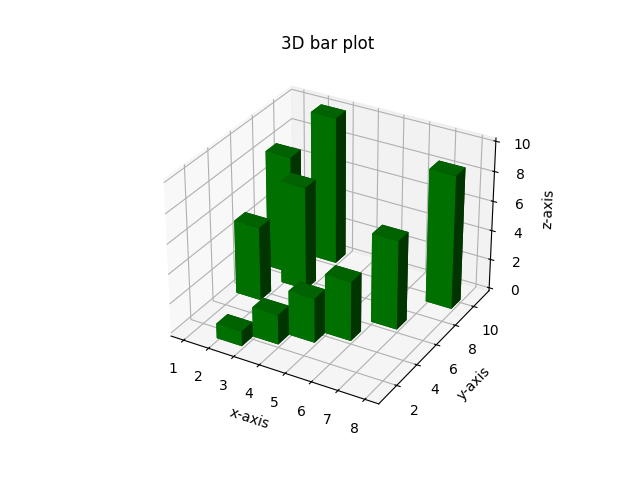

In [5]:
# creating 3d bar plot using matplotlib 
# in python

# to interact  with plot
%matplotlib widget

# importing required libraries
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# creating random dataset
xs = [2, 3, 4, 5, 1, 6, 2, 1, 7, 2]
ys = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
zs = np.zeros(10)
dx = np.ones(10)
dy = np.ones(10)
dz = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# creating figure
figg = plt.figure()
ax = figg.add_subplot(111, projection='3d')

# creating the plot
plot_geeks = ax.bar3d(xs, ys, zs, dx, 
                      dy, dz, color='green')

# setting title and labels
ax.set_title("3D bar plot")
ax.set_xlabel('x-axis')
ax.set_ylabel('y-axis')
ax.set_zlabel('z-axis')

# displaying the plot
plt.show()